# BBRv2 vs BBRv3 Dynamics Analysis

Deeper analysis of control plane behavior using ss_poll.log data.

## Research Questions
1. For RTT 10ms (low BDP): Why does v3 outperform v2 consistently?
2. For RTT 50ms (medium): Why does v3 underutilize at medium buffer sizes?
3. For RTT 100ms (high): Why does v3 become too conservative?

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

# Color scheme
C_V2 = '#d1495b'
C_V3 = '#2e86ab'

In [26]:
# Load all parsed ss_poll CSVs
out_dir = Path('../out/ss_poll_csv')
data = {}

# Map old scenario keys to new CSV file patterns
# Old key format: rtt10_0.1bdp, new CSV format: rtt10_bw100_loss*_buf0.1bdp_bbrv*.csv
scenario_map = {
    'rtt10_0.1bdp': [f'ss_poll_rtt10_bw100_loss2_buf0.1bdp_bbrv*.csv', 'RTT 10ms / 0.1 BDP'],
    'rtt10_1bdp': [f'ss_poll_rtt10_bw100_loss2_buf1bdp_bbrv*.csv', 'RTT 10ms / 1 BDP'],
    'rtt10_10bdp': [f'ss_poll_rtt10_bw100_loss2_buf10bdp_bbrv*.csv', 'RTT 10ms / 10 BDP'],
    'rtt50_0.1bdp': [f'ss_poll_rtt50_bw100_loss2_buf0.1bdp_bbrv*.csv', 'RTT 50ms / 0.1 BDP'],
    'rtt50_1bdp': [f'ss_poll_rtt50_bw100_loss2_buf1bdp_bbrv*.csv', 'RTT 50ms / 1 BDP (medium — critical)'],
    'rtt50_10bdp': [f'ss_poll_rtt50_bw100_loss2_buf10bdp_bbrv*.csv', 'RTT 50ms / 10 BDP'],
    'rtt100_0.1bdp': [f'ss_poll_rtt100_bw100_loss2_buf0.1bdp_bbrv*.csv', 'RTT 100ms / 0.1 BDP'],
    'rtt100_1bdp': [f'ss_poll_rtt100_bw100_loss2_buf1bdp_bbrv*.csv', 'RTT 100ms / 1 BDP (high RTT — critical)'],
    'rtt100_10bdp': [f'ss_poll_rtt100_bw100_loss2_buf10bdp_bbrv*.csv', 'RTT 100ms / 10 BDP'],
}

for key, (pattern, label) in scenario_map.items():
    data[key] = {}
    for version in ['v2', 'v3']:
        # Handle wildcard by converting to real files
        pattern_with_version = pattern.replace('*', f'*').replace('v*', f'{version}')
        import glob
        matches = glob.glob(str(out_dir / pattern_with_version))
        
        if matches:
            # For this BDP level, we'll aggregate loss0 and loss2
            # Just take the first one for now (loss0)
            csv_file = Path(min(matches))  # Take first (loss0 comes before loss2 alphabetically)
            df = pd.read_csv(csv_file)
            data[key][version] = df
            print(f'✓ Loaded {key:20} {version}: {len(df):6} records from {csv_file.name}')
        else:
            print(f'✗ No match for pattern: {pattern_with_version}')

print(f'\nLoaded {len(data)} scenarios')

✓ Loaded rtt10_0.1bdp         v2:   3290 records from ss_poll_rtt10_bw100_loss2_buf0.1bdp_bbrv2.csv
✓ Loaded rtt10_0.1bdp         v3:   2880 records from ss_poll_rtt10_bw100_loss2_buf0.1bdp_bbrv3.csv
✓ Loaded rtt10_1bdp           v2:   2921 records from ss_poll_rtt10_bw100_loss2_buf1bdp_bbrv2.csv
✓ Loaded rtt10_1bdp           v3:   4181 records from ss_poll_rtt10_bw100_loss2_buf1bdp_bbrv3.csv
✓ Loaded rtt10_10bdp          v2:   3727 records from ss_poll_rtt10_bw100_loss2_buf10bdp_bbrv2.csv
✓ Loaded rtt10_10bdp          v3:   4884 records from ss_poll_rtt10_bw100_loss2_buf10bdp_bbrv3.csv
✓ Loaded rtt50_0.1bdp         v2:   2287 records from ss_poll_rtt50_bw100_loss2_buf0.1bdp_bbrv2.csv
✓ Loaded rtt50_0.1bdp         v3:   2797 records from ss_poll_rtt50_bw100_loss2_buf0.1bdp_bbrv3.csv
✓ Loaded rtt50_1bdp           v2:   2462 records from ss_poll_rtt50_bw100_loss2_buf1bdp_bbrv2.csv
✓ Loaded rtt50_1bdp           v3:   3139 records from ss_poll_rtt50_bw100_loss2_buf1bdp_bbrv3.csv
✓ Loaded r

In [33]:
data['rtt10_1bdp']['v3']['phase'].unique()

<StringArray>
['PROBE_BW_CRUISE',   'PROBE_BW_DOWN', 'PROBE_BW_REFILL',     'PROBE_BW_UP',
       'PROBE_RTT']
Length: 5, dtype: str

## RTT 10ms Analysis: v3 > v2 (All Buffers)

Why does v3 consistently outperform v2 at low RTT?

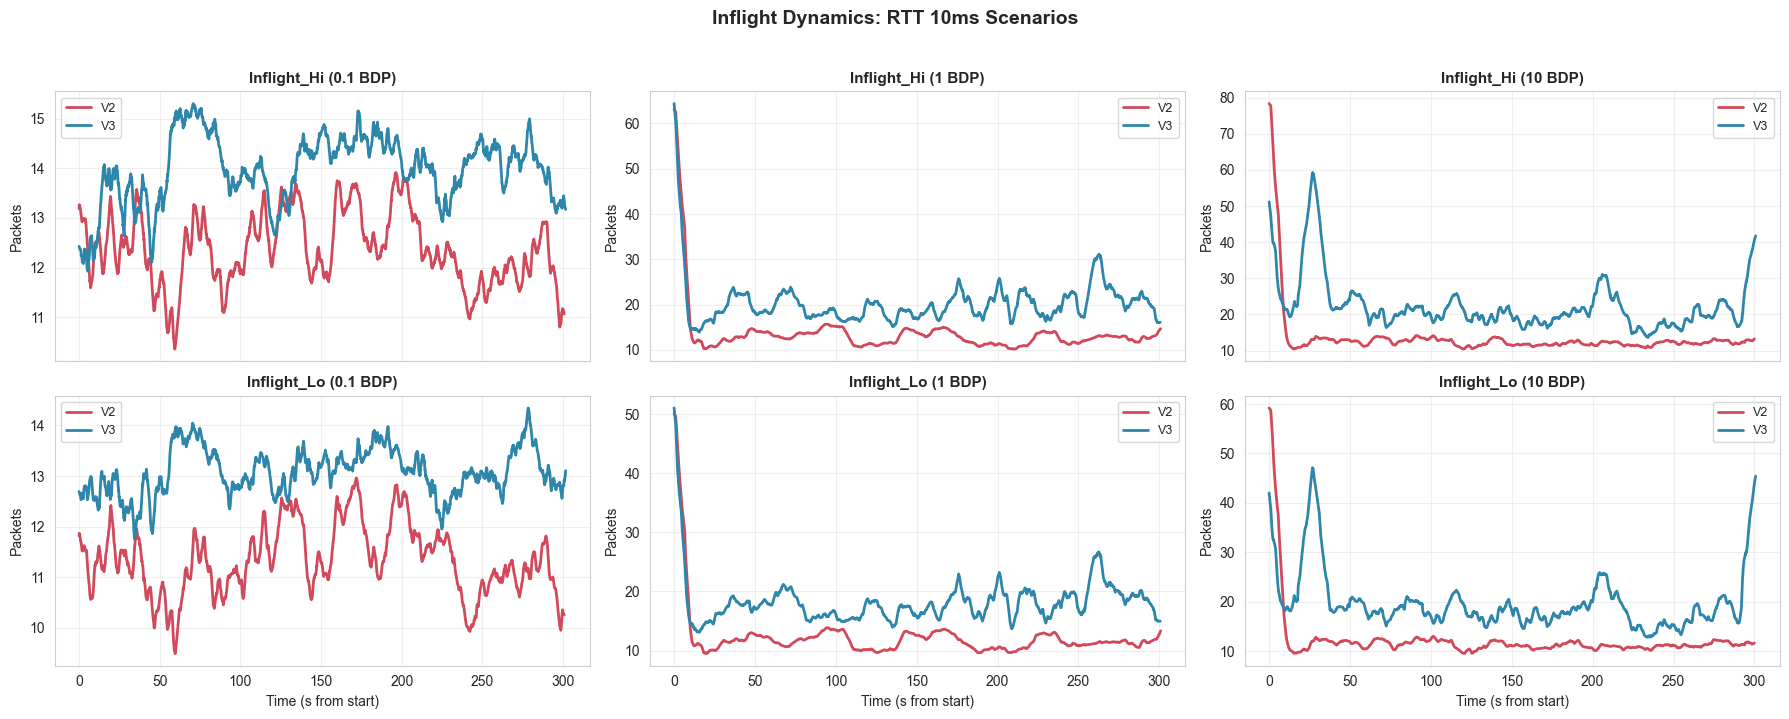

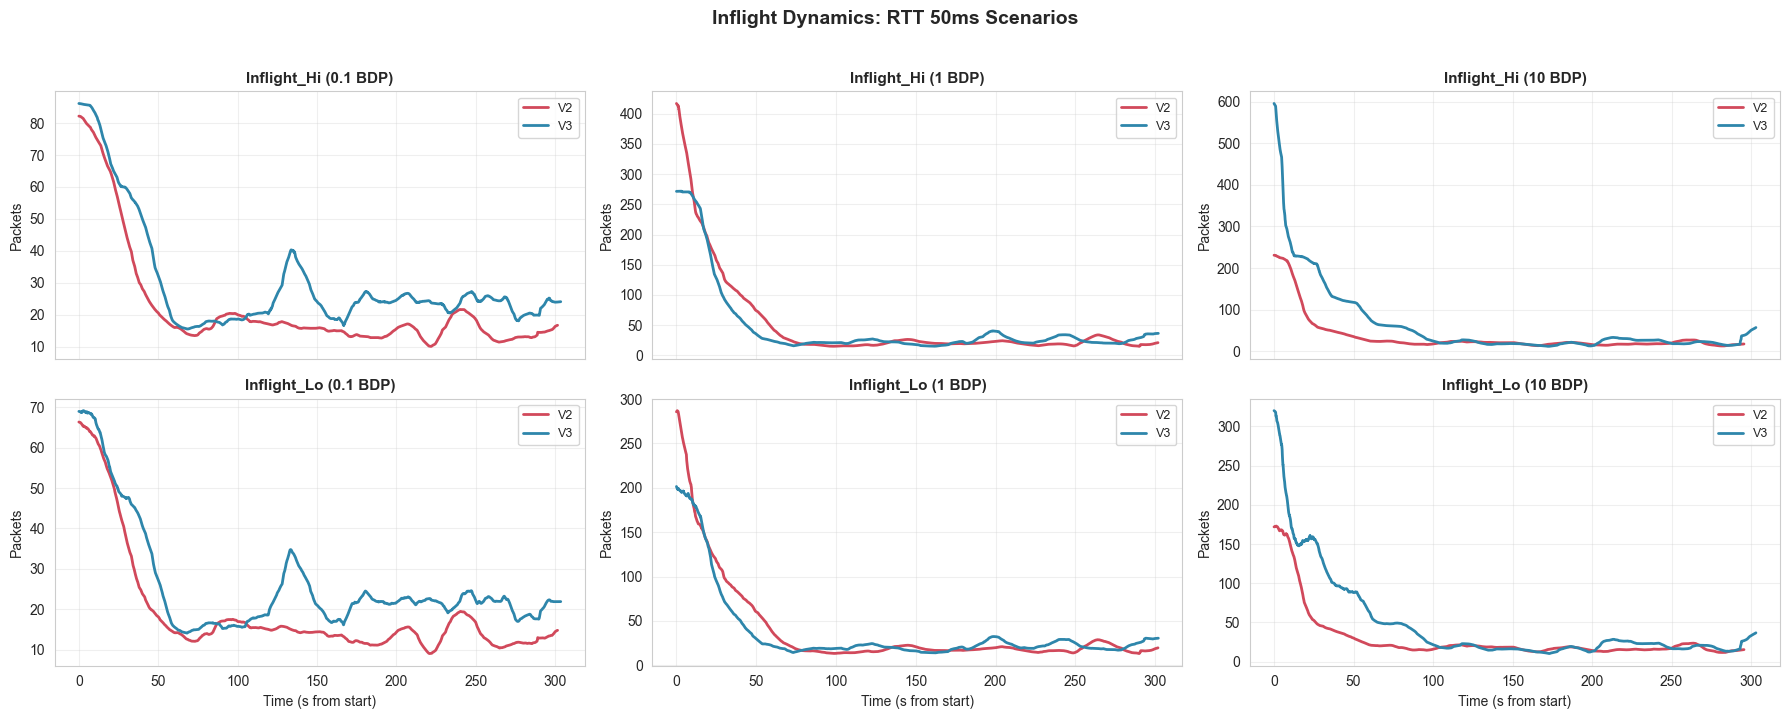

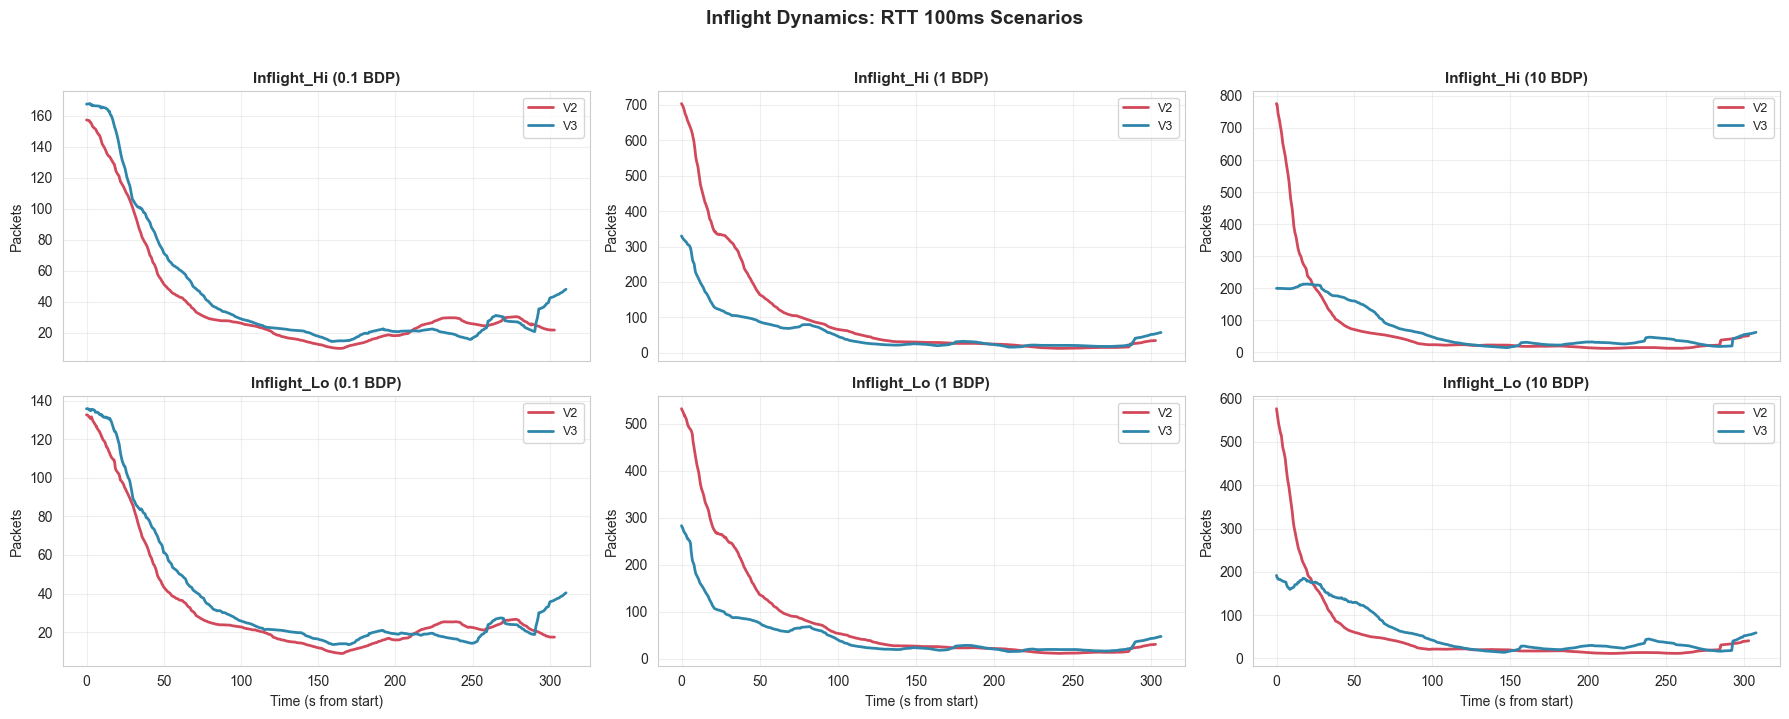

In [37]:
# Inflight dynamics: compare inflight_hi and inflight_lo for v2 vs v3
from pathlib import Path

SAVE_DIR = Path('../graphs')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def _sanitize(name):
    return name.lower().replace(' ', '_').replace('/', '_').replace(':', '').replace(',', '')

def plot_inflight_group(group_title, scenario_specs):
    n_cols = len(scenario_specs)
    fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 7), sharex='col')
    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    for col_idx, (key, label) in enumerate(scenario_specs):
        ax_hi = axes[0, col_idx]
        ax_lo = axes[1, col_idx]

        for version, color in [('v2', C_V2), ('v3', C_V3)]:
            df = data[key][version].sort_values('timestamp').reset_index(drop=True)
            x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
            window = max(15, min(150, len(df) // 10))

            inflight_hi_smooth = df['inflight_hi'].interpolate().rolling(window=window, center=True, min_periods=1).mean()
            inflight_lo_smooth = df['inflight_lo'].interpolate().rolling(window=window, center=True, min_periods=1).mean()

            ax_hi.plot(x, inflight_hi_smooth, label=version.upper(), color=color, linewidth=2)
            ax_lo.plot(x, inflight_lo_smooth, label=version.upper(), color=color, linewidth=2)

        ax_hi.set_title(f'Inflight_Hi ({label})', fontsize=11, fontweight='bold')
        ax_lo.set_title(f'Inflight_Lo ({label})', fontsize=11, fontweight='bold')
        ax_hi.set_ylabel('Packets')
        ax_lo.set_ylabel('Packets')
        ax_lo.set_xlabel('Time (s from start)')
        ax_hi.grid(True, alpha=0.3)
        ax_lo.grid(True, alpha=0.3)
        ax_hi.legend(fontsize=9)
        ax_lo.legend(fontsize=9)

    fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.02)

    # save figure
    fname = SAVE_DIR / f"{_sanitize(group_title)}.png"
    fig.savefig(str(fname), bbox_inches='tight', dpi=200)

    plt.tight_layout()
    plt.show()


plot_inflight_group(
    'Inflight Dynamics: RTT 10ms Scenarios',
    [
        ('rtt10_0.1bdp', '0.1 BDP'),
        ('rtt10_1bdp', '1 BDP'),
        ('rtt10_10bdp', '10 BDP'),
    ],
)

plot_inflight_group(
    'Inflight Dynamics: RTT 50ms Scenarios',
    [
        ('rtt50_0.1bdp', '0.1 BDP'),
        ('rtt50_1bdp', '1 BDP'),
        ('rtt50_10bdp', '10 BDP'),
    ],
)

plot_inflight_group(
    'Inflight Dynamics: RTT 100ms Scenarios',
    [
        ('rtt100_0.1bdp', '0.1 BDP'),
        ('rtt100_1bdp', '1 BDP'),
        ('rtt100_10bdp', '10 BDP'),
    ],
)




In [35]:
# from matplotlib.patches import Patch
# from pathlib import Path

# SAVE_DIR = Path('../graphs')
# SAVE_DIR.mkdir(parents=True, exist_ok=True)

# PHASE_COLORS = {
#     'PROBE_BW_DOWN': "#ff4343",
#     'PROBE_BW_UP':   "#0FAB33D8",
# }


# def _phase_segments(df):
#     df = df.sort_values('timestamp').reset_index(drop=True)
#     if df.empty:
#         return []

#     x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
#     diffs = np.diff(x.to_numpy())
#     default_step = float(np.median(diffs[diffs > 0])) if len(diffs) and np.any(diffs > 0) else 1.0
#     durations = np.append(np.where(diffs > 0, diffs, default_step), default_step)

#     segments = []
#     run_phase, run_start, run_width = df['phase'].iloc[0], float(x.iloc[0]), float(durations[0])
#     for idx in range(1, len(df)):
#         phase = df['phase'].iloc[idx]
#         if phase == run_phase:
#             run_width += float(durations[idx])
#         else:
#             segments.append((run_start, run_width, run_phase))
#             run_phase, run_start, run_width = phase, float(x.iloc[idx]), float(durations[idx])
#     segments.append((run_start, run_width, run_phase))
#     return segments


# def plot_phase_flame_group(group_title, scenario_specs):
#     fig, axes = plt.subplots(
#         len(scenario_specs), 1,
#         figsize=(18, max(3.0, 2.6 * len(scenario_specs))),
#         sharex=True,
#         facecolor='#f5f5f5',
#     )
#     if len(scenario_specs) == 1:
#         axes = [axes]

#     legend_handles = [Patch(facecolor=c, edgecolor='none', label=p) for p, c in PHASE_COLORS.items()]

#     for ax, (key, label) in zip(axes, scenario_specs):
#         ax.set_facecolor('#fafafa')
#         for version, line_color, y_base in [('v2', C_V2, 12), ('v3', C_V3, 0)]:
#             df = data[key][version].sort_values('timestamp').reset_index(drop=True)
#             for start, width, phase in _phase_segments(df):
#                 if phase not in PHASE_COLORS:
#                     continue
#                 ax.broken_barh(
#                     [(start, width)], (y_base, 8),
#                     facecolors=PHASE_COLORS[phase],
#                     edgecolors='#222222', linewidth=0.25, alpha=0.98,
#                 )
#             ax.text(-0.01, y_base + 4, version.upper(), va='center', ha='right',
#                     fontsize=10, fontweight='bold', color=line_color,
#                     transform=ax.get_yaxis_transform())

#         ax.set_ylim(-2, 22)
#         ax.set_yticks([4, 16])
#         ax.set_yticklabels(['V3', 'V2'])
#         ax.set_title(label, fontsize=11, fontweight='bold', loc='left')
#         ax.grid(True, axis='x', alpha=0.25, color='#cccccc')
#         ax.grid(False, axis='y')

#     axes[-1].set_xlabel('Time (s from start)')
#     fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.01)
#     fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.99))

#     fname = SAVE_DIR / f"{group_title.lower().replace(' ', '_').replace('/', '_').replace(':', '')}_flame.png"
#     fig.savefig(str(fname), bbox_inches='tight', dpi=200)
#     plt.tight_layout()
#     plt.show()


# plot_phase_flame_group(
#     'BBR State Flame Graph: RTT 10ms Scenarios',
#     [('rtt10_0.1bdp', '0.1 BDP'), ('rtt10_1bdp', '1 BDP'), ('rtt10_10bdp', '10 BDP')],
# )

# plot_phase_flame_group(
#     'BBR State Flame Graph: RTT 50ms Scenarios',
#     [('rtt50_0.1bdp', '0.1 BDP'), ('rtt50_1bdp', '1 BDP'), ('rtt50_10bdp', '10 BDP')],
# )

# plot_phase_flame_group(
#     'BBR State Flame Graph: RTT 100ms Scenarios',
#     [('rtt100_0.1bdp', '0.1 BDP'), ('rtt100_1bdp', '1 BDP'), ('rtt100_10bdp', '10 BDP')],
# )

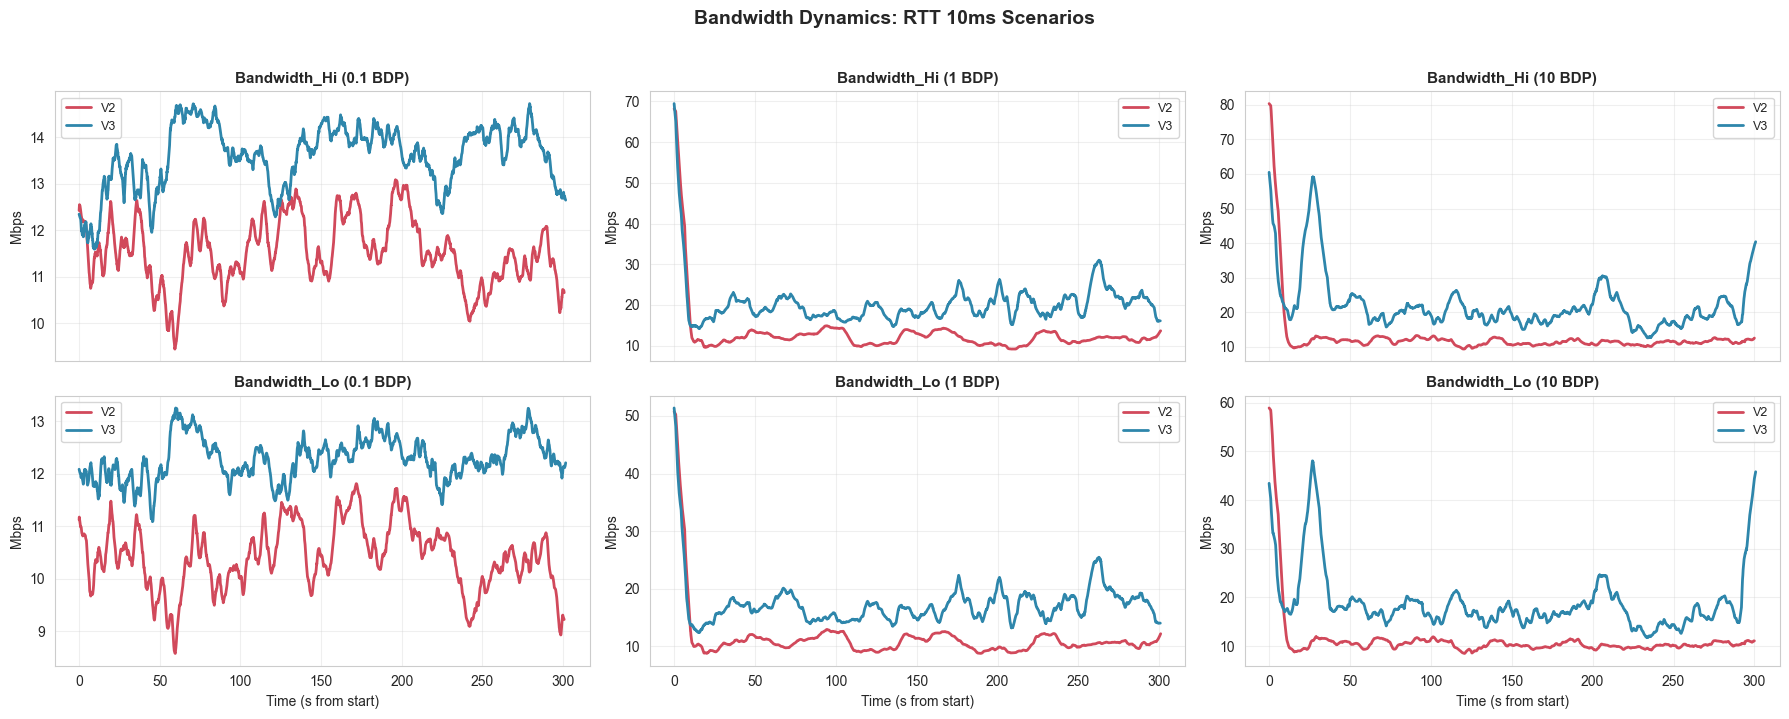

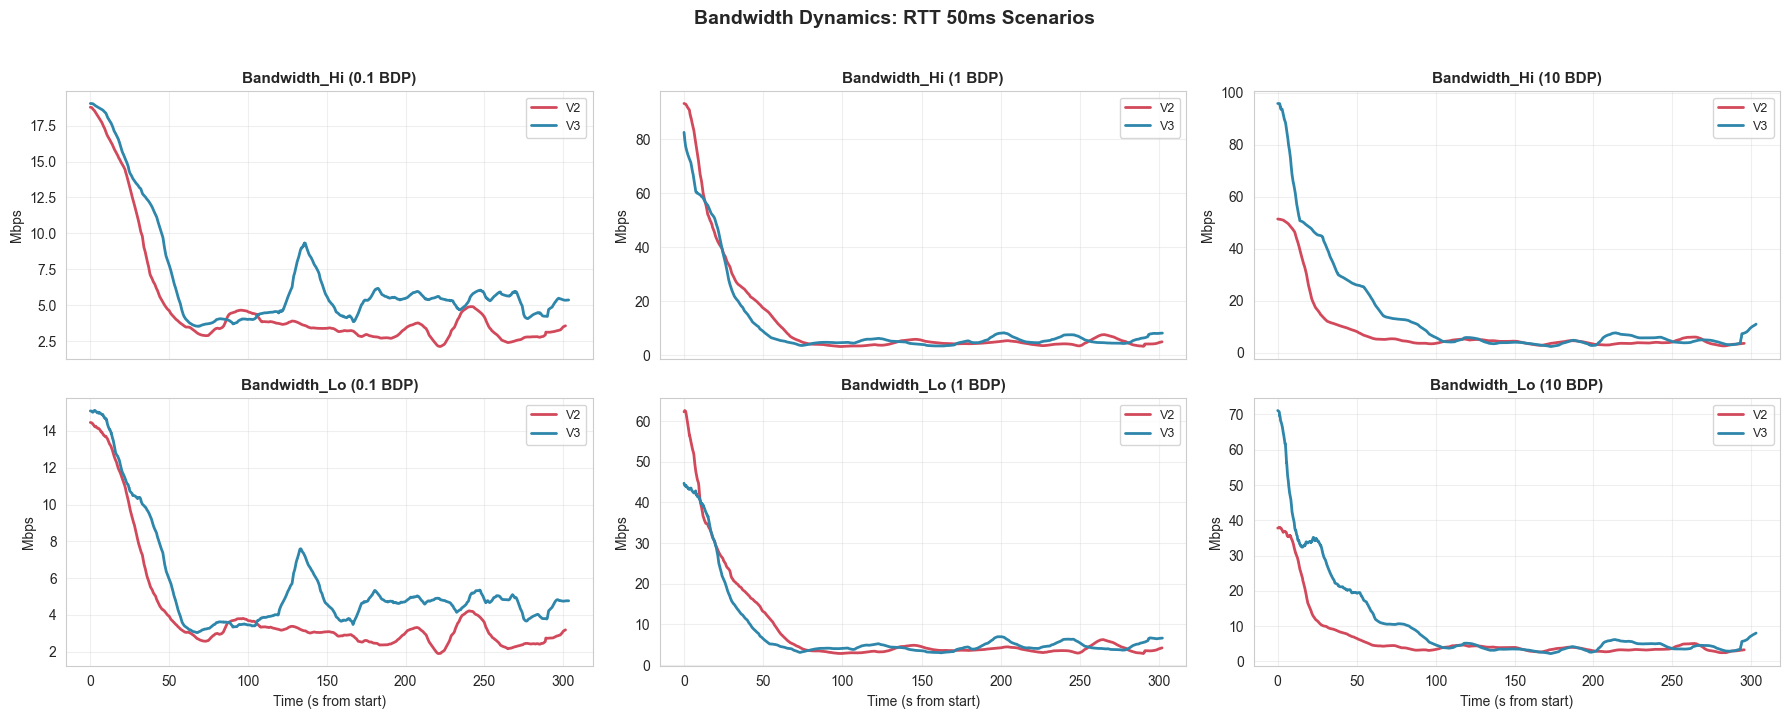

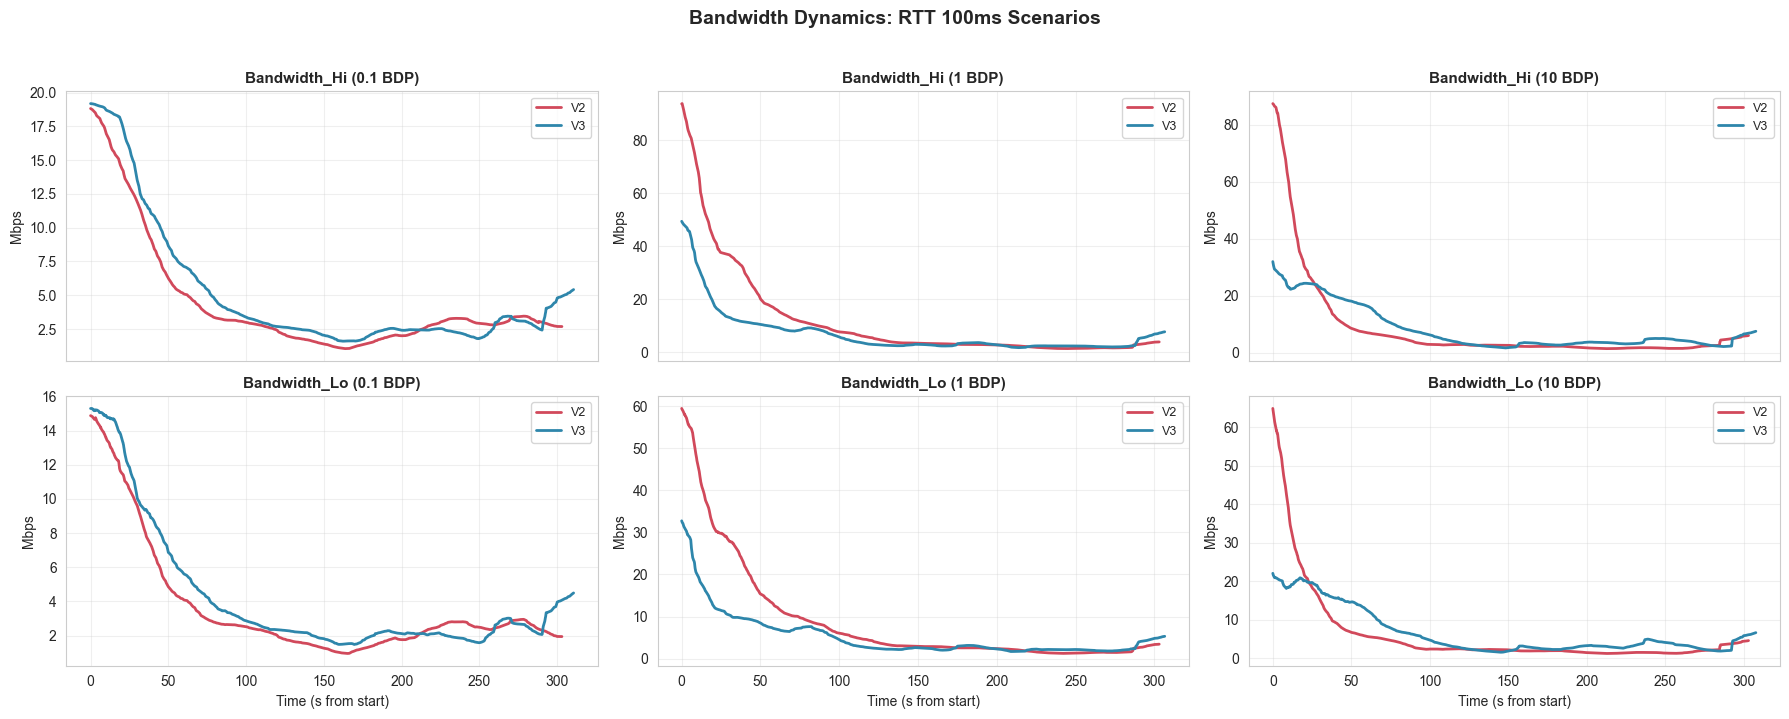

In [38]:
def plot_bandwidth_group(group_title, scenario_specs):
    n_cols = len(scenario_specs)
    fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 7), sharex='col')
    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    for col_idx, (key, label) in enumerate(scenario_specs):
        ax_hi = axes[0, col_idx]
        ax_lo = axes[1, col_idx]

        for version, color in [('v2', C_V2), ('v3', C_V3)]:
            df = data[key][version].sort_values('timestamp').reset_index(drop=True)
            x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
            window = max(15, min(150, len(df) // 10))

            bw_hi_smooth = (df['bw_hi'] / 1e6).interpolate().rolling(window=window, center=True, min_periods=1).mean()
            bw_lo_smooth = (df['bw_lo'] / 1e6).interpolate().rolling(window=window, center=True, min_periods=1).mean()

            ax_hi.plot(x, bw_hi_smooth, label=version.upper(), color=color, linewidth=2)
            ax_lo.plot(x, bw_lo_smooth, label=version.upper(), color=color, linewidth=2)

        ax_hi.set_title(f'Bandwidth_Hi ({label})', fontsize=11, fontweight='bold')
        ax_lo.set_title(f'Bandwidth_Lo ({label})', fontsize=11, fontweight='bold')
        ax_hi.set_ylabel('Mbps')
        ax_lo.set_ylabel('Mbps')
        ax_lo.set_xlabel('Time (s from start)')
        ax_hi.grid(True, alpha=0.3)
        ax_lo.grid(True, alpha=0.3)
        ax_hi.legend(fontsize=9)
        ax_lo.legend(fontsize=9)

    fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.02)

    fname = SAVE_DIR / f"{_sanitize(group_title)}.png"
    fig.savefig(str(fname), bbox_inches='tight', dpi=200)

    plt.tight_layout()
    plt.show()


plot_bandwidth_group(
    'Bandwidth Dynamics: RTT 10ms Scenarios',
    [
        ('rtt10_0.1bdp', '0.1 BDP'),
        ('rtt10_1bdp', '1 BDP'),
        ('rtt10_10bdp', '10 BDP'),
    ],
)

plot_bandwidth_group(
    'Bandwidth Dynamics: RTT 50ms Scenarios',
    [
        ('rtt50_0.1bdp', '0.1 BDP'),
        ('rtt50_1bdp', '1 BDP'),
        ('rtt50_10bdp', '10 BDP'),
    ],
)

plot_bandwidth_group(
    'Bandwidth Dynamics: RTT 100ms Scenarios',
    [
        ('rtt100_0.1bdp', '0.1 BDP'),
        ('rtt100_1bdp', '1 BDP'),
        ('rtt100_10bdp', '10 BDP'),
    ],
)

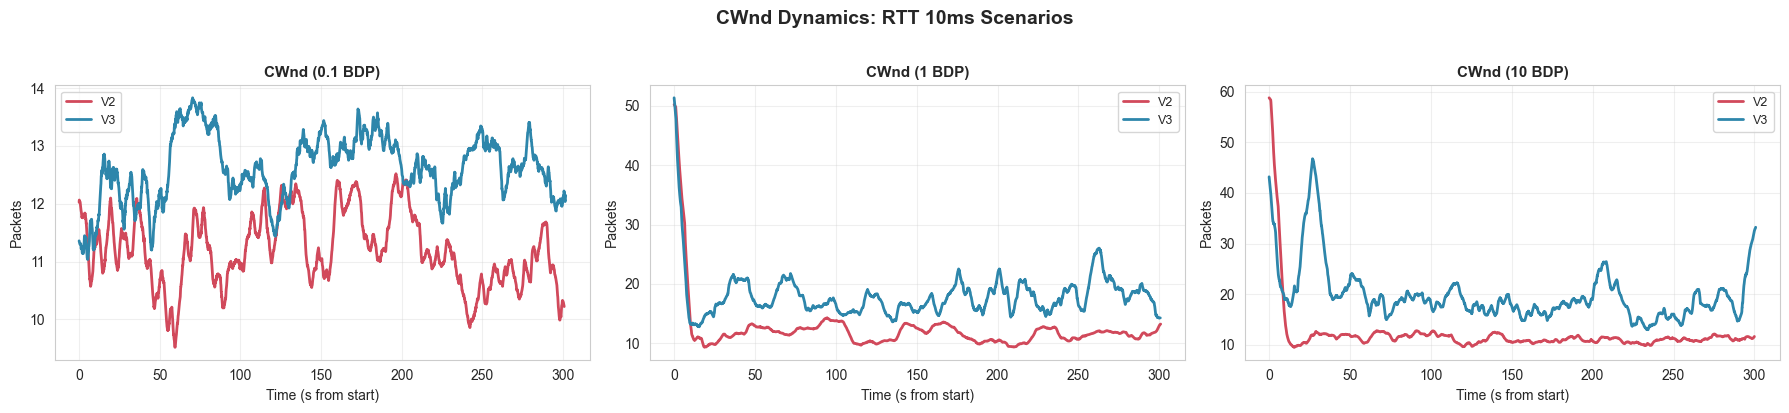

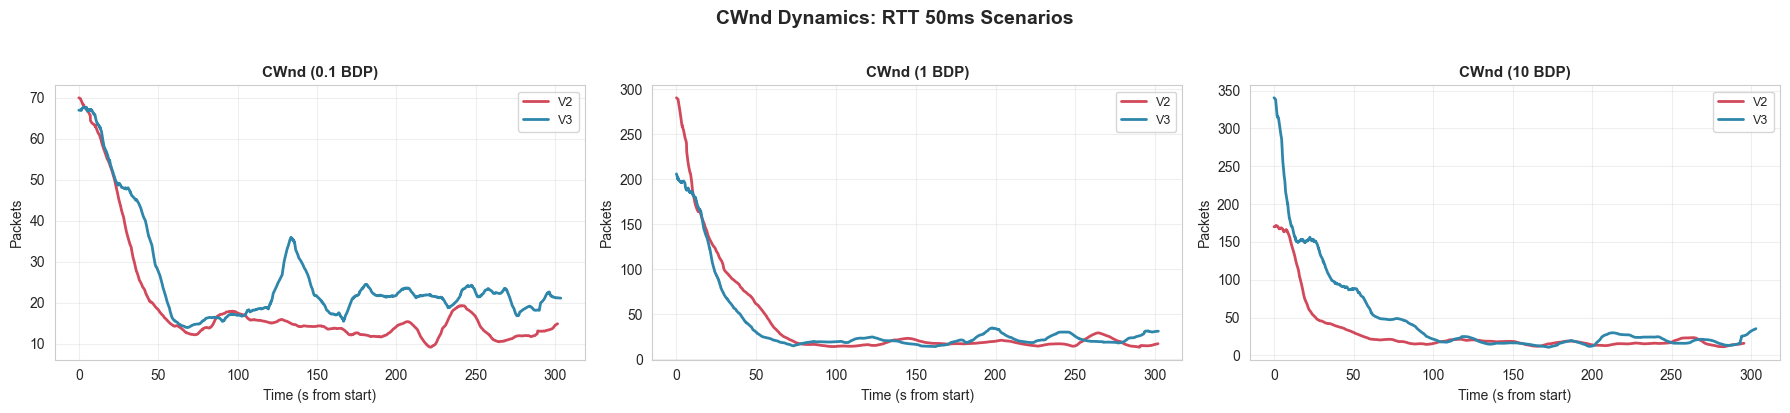

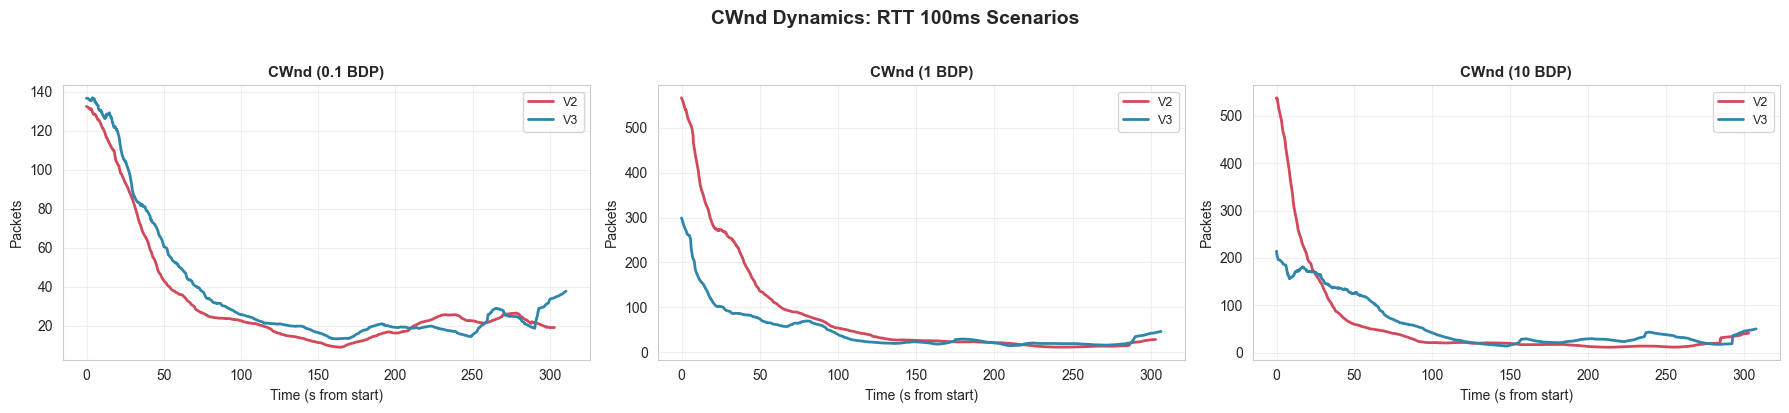

In [39]:
def plot_cwnd_group(group_title, scenario_specs):
    n_cols = len(scenario_specs)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4), sharex='col')
    if n_cols == 1:
        axes = np.array(axes).reshape(1, 1)

    for col_idx, (key, label) in enumerate(scenario_specs):
        ax = axes[col_idx] if n_cols > 1 else axes[0, 0]

        for version, color in [('v2', C_V2), ('v3', C_V3)]:
            df = data[key][version].sort_values('timestamp').reset_index(drop=True)
            x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
            window = max(15, min(150, len(df) // 10))

            cwnd_smooth = df['cwnd'].interpolate().rolling(window=window, center=True, min_periods=1).mean()

            ax.plot(x, cwnd_smooth, label=version.upper(), color=color, linewidth=2)

        ax.set_title(f'CWnd ({label})', fontsize=11, fontweight='bold')
        ax.set_ylabel('Packets')
        ax.set_xlabel('Time (s from start)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.02)

    fname = SAVE_DIR / f"{_sanitize(group_title)}.png"
    fig.savefig(str(fname), bbox_inches='tight', dpi=200)

    plt.tight_layout()
    plt.show()


plot_cwnd_group(
    'CWnd Dynamics: RTT 10ms Scenarios',
    [
        ('rtt10_0.1bdp', '0.1 BDP'),
        ('rtt10_1bdp', '1 BDP'),
        ('rtt10_10bdp', '10 BDP'),
    ],
)

plot_cwnd_group(
    'CWnd Dynamics: RTT 50ms Scenarios',
    [
        ('rtt50_0.1bdp', '0.1 BDP'),
        ('rtt50_1bdp', '1 BDP'),
        ('rtt50_10bdp', '10 BDP'),
    ],
)

plot_cwnd_group(
    'CWnd Dynamics: RTT 100ms Scenarios',
    [
        ('rtt100_0.1bdp', '0.1 BDP'),
        ('rtt100_1bdp', '1 BDP'),
        ('rtt100_10bdp', '10 BDP'),
    ],
)

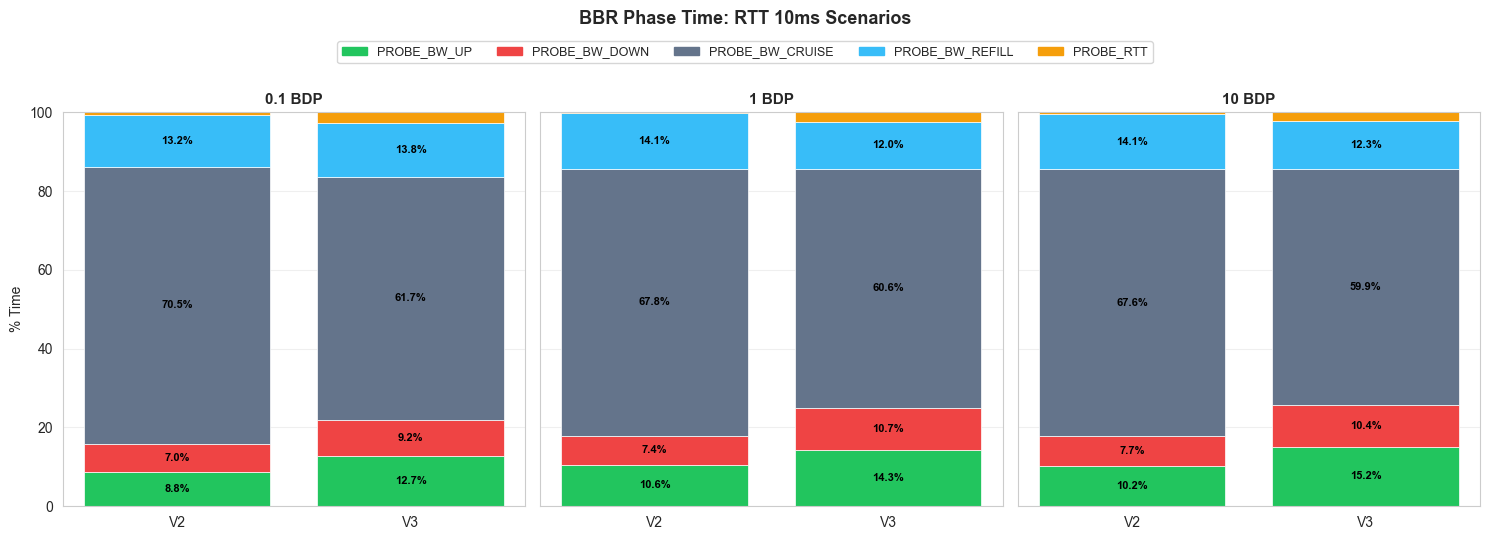

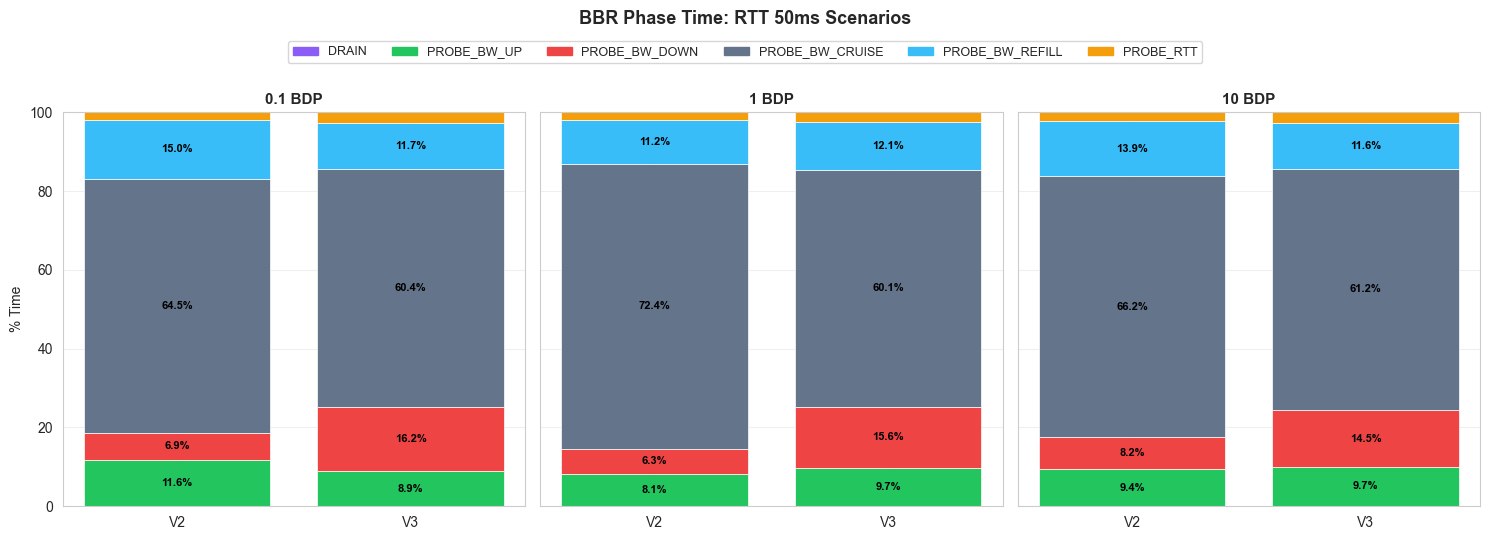

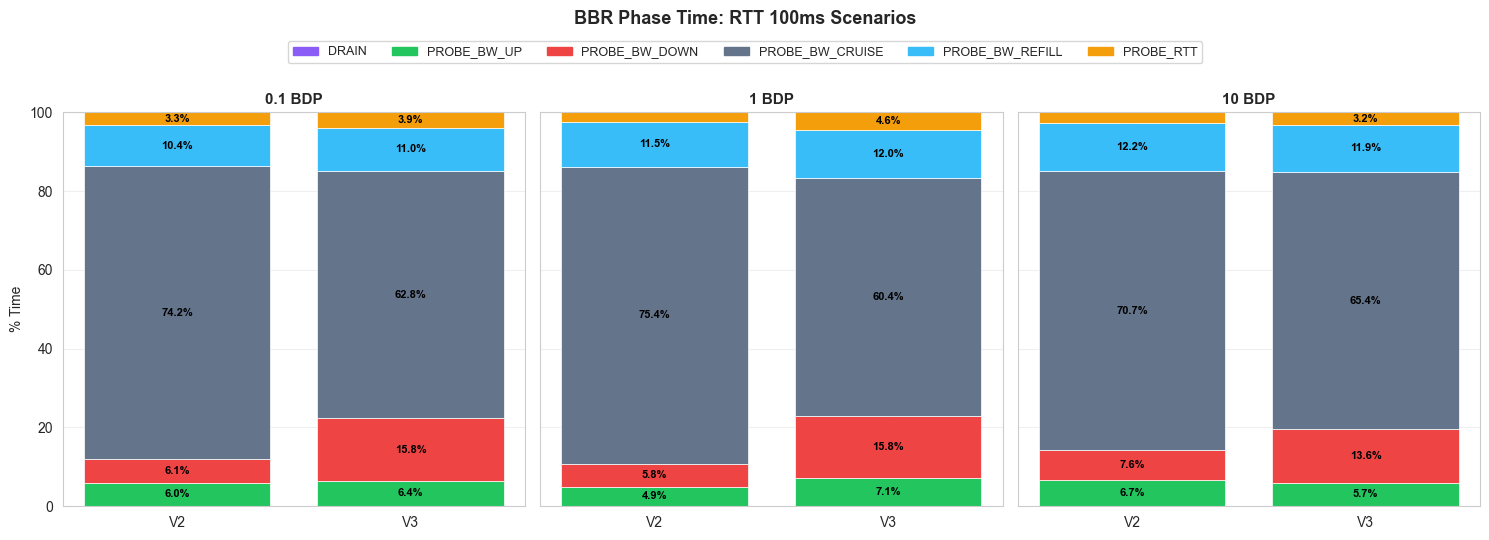

In [34]:
from pathlib import Path
import pandas as pd

SAVE_DIR = Path('../graphs')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

PHASE_COLORS = {
    'STARTUP':         "#f97316",  # vivid orange
    'DRAIN':           "#8b5cf6",  # violet
    'PROBE_BW_UP':     "#22c55e",  # emerald green
    'PROBE_BW_DOWN':   "#ef4444",  # coral red
    'PROBE_BW_CRUISE': "#64748b",  # slate grey
    'PROBE_BW_REFILL': "#38bdf8",  # sky blue
    'PROBE_RTT':       "#f59e0b",  # amber
}


def phase_pct(df):
    """Return a Series of % time spent in each phase."""
    df = df.sort_values('timestamp').reset_index(drop=True)
    x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    diffs = np.diff(x.to_numpy())
    default_step = float(np.median(diffs[diffs > 0])) if len(diffs) and np.any(diffs > 0) else 1.0
    durations = np.append(np.where(diffs > 0, diffs, default_step), default_step)

    time_by_phase = {}
    for phase, dur in zip(df['phase'], durations):
        time_by_phase[phase] = time_by_phase.get(phase, 0.0) + dur

    total = sum(time_by_phase.values())
    return {p: 100.0 * t / total for p, t in time_by_phase.items()}


def plot_phase_pct_group(group_title, scenario_specs):
    rows = []
    for key, label in scenario_specs:
        for version in ('v2', 'v3'):
            pct = phase_pct(data[key][version])
            rows.append({'scenario': label, 'version': version.upper(), **pct})

    df = pd.DataFrame(rows).fillna(0)
    phases = [p for p in PHASE_COLORS if p in df.columns]

    scenarios = [label for _, label in scenario_specs]
    n = len(scenarios)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, label in zip(axes, scenarios):
        subset = df[df['scenario'] == label].set_index('version')
        bottom = np.zeros(2)
        versions = ['V2', 'V3']
        for phase in phases:
            vals = [subset.loc[v, phase] if phase in subset.columns else 0.0 for v in versions]
            ax.bar(versions, vals, bottom=bottom,
                   color=PHASE_COLORS[phase], label=phase, edgecolor='white', linewidth=0.5)
            for i, (v, b) in enumerate(zip(vals, bottom)):
                if v >= 3:
                    ax.text(i, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                            fontsize=8, fontweight='bold', color='black')
            bottom += np.array(vals)

        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.set_ylabel('% Time' if ax is axes[0] else '')
        ax.grid(True, axis='y', alpha=0.3)

    handles = [plt.Rectangle((0, 0), 1, 1, color=PHASE_COLORS[p]) for p in phases]
    fig.legend(handles, phases, loc='upper center', ncol=len(phases),
               bbox_to_anchor=(0.5, 1.02), frameon=True, fontsize=9)
    fig.suptitle(group_title, fontsize=13, fontweight='bold', y=1.07)

    fname = SAVE_DIR / f"{group_title.lower().replace(' ', '_').replace('/', '_').replace(':', '')}_pct.png"
    fig.savefig(str(fname), bbox_inches='tight', dpi=200)
    plt.tight_layout()
    plt.show()


plot_phase_pct_group(
    'BBR Phase Time: RTT 10ms Scenarios',
    [('rtt10_0.1bdp', '0.1 BDP'), ('rtt10_1bdp', '1 BDP'), ('rtt10_10bdp', '10 BDP')],
)

plot_phase_pct_group(
    'BBR Phase Time: RTT 50ms Scenarios',
    [('rtt50_0.1bdp', '0.1 BDP'), ('rtt50_1bdp', '1 BDP'), ('rtt50_10bdp', '10 BDP')],
)

plot_phase_pct_group(
    'BBR Phase Time: RTT 100ms Scenarios',
    [('rtt100_0.1bdp', '0.1 BDP'), ('rtt100_1bdp', '1 BDP'), ('rtt100_10bdp', '10 BDP')],
)